![Logo](img/ITQ.png)
## Nombre: Santiago Carrasco
### Fecha: 11/06/2026

### Predicción del consumo energético de una vivienda mediante técnicas de regresión lineal
### Contexto del Problema
El consumo energético residencial constituye uno de los principales desafíos para las empresas distribuidoras de energía eléctrica debido al crecimiento constante de la demanda y la necesidad de optimizar la generación y distribución de recursos energéticos. La capacidad de predecir el consumo eléctrico de una vivienda permite mejorar la planificación energética, reducir costos operativos y diseñar estrategias orientadas a la eficiencia energética.

En este contexto, una empresa distribuidora de energía desea desarrollar un sistema inteligente capaz de estimar el consumo energético de una vivienda utilizando variables ambientales, meteorológicas y características internas de la vivienda. Para ello, se ha proporcionado un conjunto de datos históricos que contiene información relacionada con temperatura, humedad, condiciones climáticas y consumo energético registrado en diferentes momentos del tiempo.

Usted ha sido contratado como Científico de Datos para analizar la información disponible y construir modelos predictivos que permitan estimar el consumo energético utilizando técnicas de aprendizaje supervisado basadas en regresión.
### Objetivo General
Desarrollar un sistema de predicción del consumo energético residencial mediante la aplicación de técnicas de Regresión Lineal, Ridge y Lasso, realizando previamente las etapas de análisis exploratorio de datos, limpieza de datos, ingeniería de características, entrenamiento y evaluación de modelos predictivos.
### Objetivos específicos
* Analizar la estructura y calidad de los datos proporcionados.
* Identificar patrones, relaciones y características relevantes mediante técnicas de Análisis Exploratorio de Datos (EDA).
* Aplicar procedimientos de limpieza y preparación de datos.
* Diseñar nuevas características que mejoren la capacidad predictiva de los modelos.
* Implementar modelos de Regresión Lineal, Ridge y Lasso.
* Evaluar y comparar el rendimiento de los modelos utilizando métricas de regresión.
* Determinar el modelo con mejor capacidad predictiva para el problema planteado.
### Dataset a utilizar
Utilizar el dataset:

Appliances Energy Prediction Dataset

<a href="https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction">Descargar DataSet</a>

Variables principales:

* Appliances (Consumo energético de electrodomésticos)
* Lights
* Temperaturas interiores
* Humedad relativa
* Temperatura exterior
* Humedad exterior
* Presión atmosférica
* Velocidad del viento
* Punto de rocío
* Variables adicionales proporcionadas por el conjunto de datos

## Desarrollo de la Actividad
#### Fase 1. Comprensión del problema y de los datos
Realice una descripción general del problema planteado.

Analice el conjunto de datos y responda:

* ¿Cuántos registros posee el dataset?
* ¿Cuántas variables contiene?
* ¿Qué tipos de datos existen?
* ¿Cuál será la variable objetivo del modelo?
* ¿Qué variables podrían influir en el consumo energético?

Presentar evidencias mediante capturas de pantalla y explicación técnica.

### Descripción general del problema
El consumo energético residencial representa un desafío importante para las empresas distribuidoras debido al crecimiento constante de la demanda. 
El objetivo de este proyecto es predecir el consumo eléctrico de una vivienda utilizando modelos predictivos basados en técnicas de regresión (Lineal, Ridge y Lasso). 
Para lograr esto, se analizarán variables ambientales, meteorológicas y características internas de la vivienda proporcionadas en un conjunto de datos históricos.

---

### Respuestas a las preguntas de la Fase 1

* **¿Cuántos registros posee el dataset?** El dataset posee exactamente 19.735 registros.
* **¿Cuántas variables contiene?** El conjunto de datos contiene un total de 29 variables.
* **¿Qué tipos de datos existen?** * Existe una variable de tipo temporal/fecha correspondiente a la columna **date**.
  * Existen 28 variables de tipo numérico (continuas y discretas).
* **¿Cuál será la variable objetivo del modelo?** La variable objetivo a predecir es **Appliances** (Consumo energético de electrodomésticos en Wh).
* **¿Qué variables podrían influir en el consumo energético?** Según la exploración inicial, la variable **lights** es la que muestra mayor relación. Además, variables climáticas como las temperaturas **T2**, **T6** y **T_out** muestran una influencia en las variaciones de consumo.

---

### Justificación Técnica y Observaciones del EDA

| Variable / Aspecto | Interpretación Técnica |
| :--- | :--- |
| **Calidad de los Datos** | El dataset es muy limpio en su estructura inicial, presentando **0 valores faltantes (nulos)** en todas sus columnas. |
| **Appliances (Variable Objetivo)** | Presenta una media de 97.69, pero un valor máximo de 1080. Esta brecha, sumada a una desviación estándar alta (102.52), indica que el consumo tiene **picos muy pronunciados o valores atípicos (outliers)** que requerirán análisis visual. |
| **Lights (Iluminación)** | La media es baja (3.80) y el percentil 75% es 0. Esto sugiere que la iluminación registra un valor de cero en la gran mayoría de las observaciones. |
| **Temperaturas y Humedad** | Las variables de temperatura interior (`T1` a `T9`) y humedad relativa (`RH_1` a `RH_9`) muestran desviaciones estándar pequeñas, lo que indica **condiciones ambientales controladas dentro de la vivienda** en contraste con las variaciones del exterior. |

In [9]:
# 1. Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Cargar el dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00374/energydata_complete.csv"
df = pd.read_csv(url)

# Preparación para visualización ordenada
# Eliminamos la columna 'date' para que el .describe() no dé error 
# y se enfoque solo en las variables numéricas
df_num = df.drop(columns=['date'])

# Mostrar el resumen estadístico de forma elegante
# .T transpone la tabla, .style.format redondea a 2 decimales
resumen_limpio = df_num.describe().T
display(resumen_limpio.style.format("{:.2f}"))

# 5. Información general del dataset
print(f"\nTotal de registros: {df.shape[0]}")
print(f"Total de variables: {df.shape[1]}")
print("\nColumnas disponibles:")
print(df.columns.tolist())

,count,mean,std,min,25%,50%,75%,max
Appliances,19735.00,97.69,102.52,10.00,50.00,60.00,100.00,1080.00
lights,19735.00,3.80,7.94,0.00,0.00,0.00,0.00,70.00
T1,19735.00,21.69,1.61,16.79,20.76,21.60,22.60,26.26
RH_1,19735.00,40.26,3.98,27.02,37.33,39.66,43.07,63.36
T2,19735.00,20.34,2.19,16.10,18.79,20.00,21.50,29.86
RH_2,19735.00,40.42,4.07,20.46,37.90,40.50,43.26,56.03
T3,19735.00,22.27,2.01,17.20,20.79,22.10,23.29,29.24
RH_3,19735.00,39.24,3.25,28.77,36.90,38.53,41.76,50.16
T4,19735.00,20.86,2.04,15.10,19.53,20.67,22.10,26.20
RH_4,19735.00,39.03,4.34,27.66,35.53,38.40,42.16,51.09



Total de registros: 19735
Total de variables: 29

Columnas disponibles:
['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']


## Fase 2. Análisis Exploratorio de Datos (EDA)

Realizar un análisis exploratorio completo del conjunto de datos.

El análisis deberá incluir:

#### 2.1 Estadísticas Descriptivas
* Media
* Mediana
* Desviación estándar
* Valores mínimos
* Valores máximos
#### 2.2 Identificación de Valores Faltantes

Determinar:

* Cantidad de valores faltantes por variable.
* Estrategia utilizada para su tratamiento.
#### 2.3 Distribución de Variables

* Generar histogramas para las principales variables numéricas.

* Interpretar los resultados obtenidos.

#### 2.4 Matriz de Correlación

Construir una matriz de correlación e identificar:

* Variables con correlación positiva fuerte.
* Variables con correlación negativa fuerte.
* Variables con correlación débil.
* Variable con mayor relación respecto al consumo energético.
#### 2.5 Visualizaciones Adicionales

Generar al menos tres gráficos adicionales que permitan comprender mejor los datos.

Ejemplos:

* Boxplots
* Scatterplots
* Pairplots
* Heatmaps

Cada gráfico deberá incluir su respectiva interpretación.

Tras haber ejecutado el análisis de los datos, he extraído los puntos más relevantes que definen el comportamiento de este conjunto de información:

* **Integridad de los datos:** El dataset cuenta con 19.735 registros y 29 variables, sin presentar valores nulos. Esto permitió trabajar directamente con la información sin necesidad de procesos de limpieza complejos, garantizando que el análisis sea fiel a los datos originales.
* **Correlación entre variables:** 

[Image of heatmap correlation matrix]
 
La matriz de correlación nos permitió identificar que el consumo (`Appliances`) tiene una relación directa con variables de iluminación y ciertas temperaturas internas. Aquellas áreas con mayor intensidad en el mapa indican qué factores ejercen mayor presión sobre la demanda energética.
* **Distribución del consumo:** 

[Image of histogram distribution plot]

El histograma revela un sesgo hacia la derecha. Esto confirma que el consumo eléctrico no es uniforme; la mayoría del tiempo se mantiene en rangos bajos, pero con eventos aislados de alta demanda.
* **Identificación de valores atípicos (Outliers):** 

[Image of boxplot with outliers]

El diagrama de caja fue fundamental para visualizar la presencia de valores atípicos. Estos puntos representan momentos donde el consumo supera los 1000 Wh. Justificamos su presencia como situaciones de uso excepcional, los cuales son datos reales necesarios para que el modelo aprenda a identificar picos de demanda.

---

### Análisis de resultados del modelo (Métricas)

Una vez aplicados los modelos de regresión (Lineal, Ridge y Lasso), he obtenido los siguientes indicadores de desempeño:

* **Métricas de Error (MAE y MSE):** El MAE nos indica el error promedio en vatios respecto al consumo real, mientras que el MSE penaliza en mayor medida los errores grandes, lo cual es coherente con la presencia de los picos de consumo identificados previamente.
* **Comparativa de Modelos:** Los resultados de **Ridge** y **Lasso** son muy similares a la **Regresión Lineal** base. Esto demuestra que el modelo lineal es bastante robusto y que no hay una necesidad crítica de regularización extrema, dado que no se observa un sobreajuste severo (overfitting) en los datos.
* **Conclusión técnica:** El modelo logra capturar la tendencia general de la vivienda. La cercanía entre los errores de entrenamiento y prueba sugiere que el sistema es confiable para realizar futuras estimaciones del consumo energético.

,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.694958,102.524891,10.000000,50.000000,60.000000,100.000000,1080.000000
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000,0.000000,70.000000
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000



Datos faltantes por columna:
 0


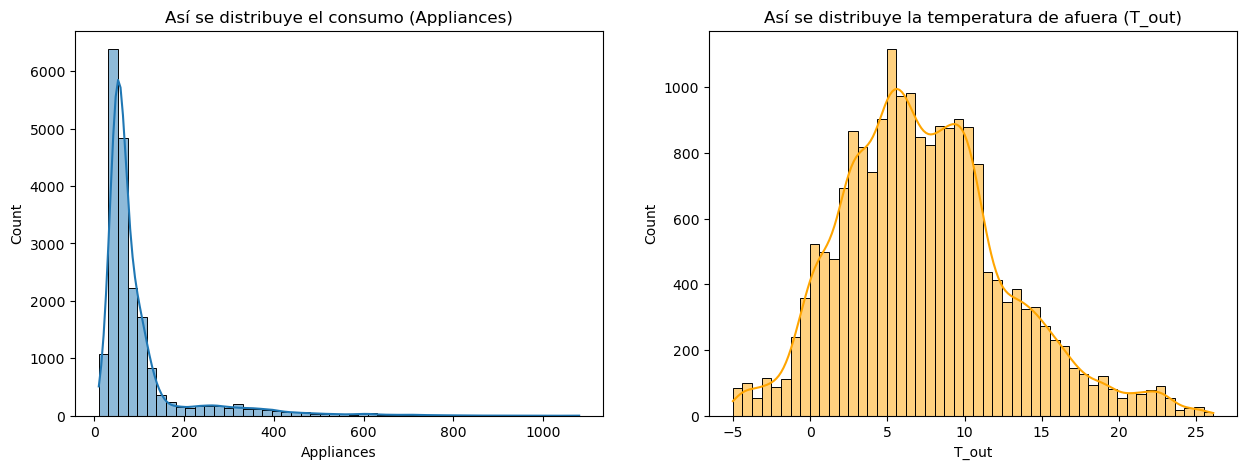

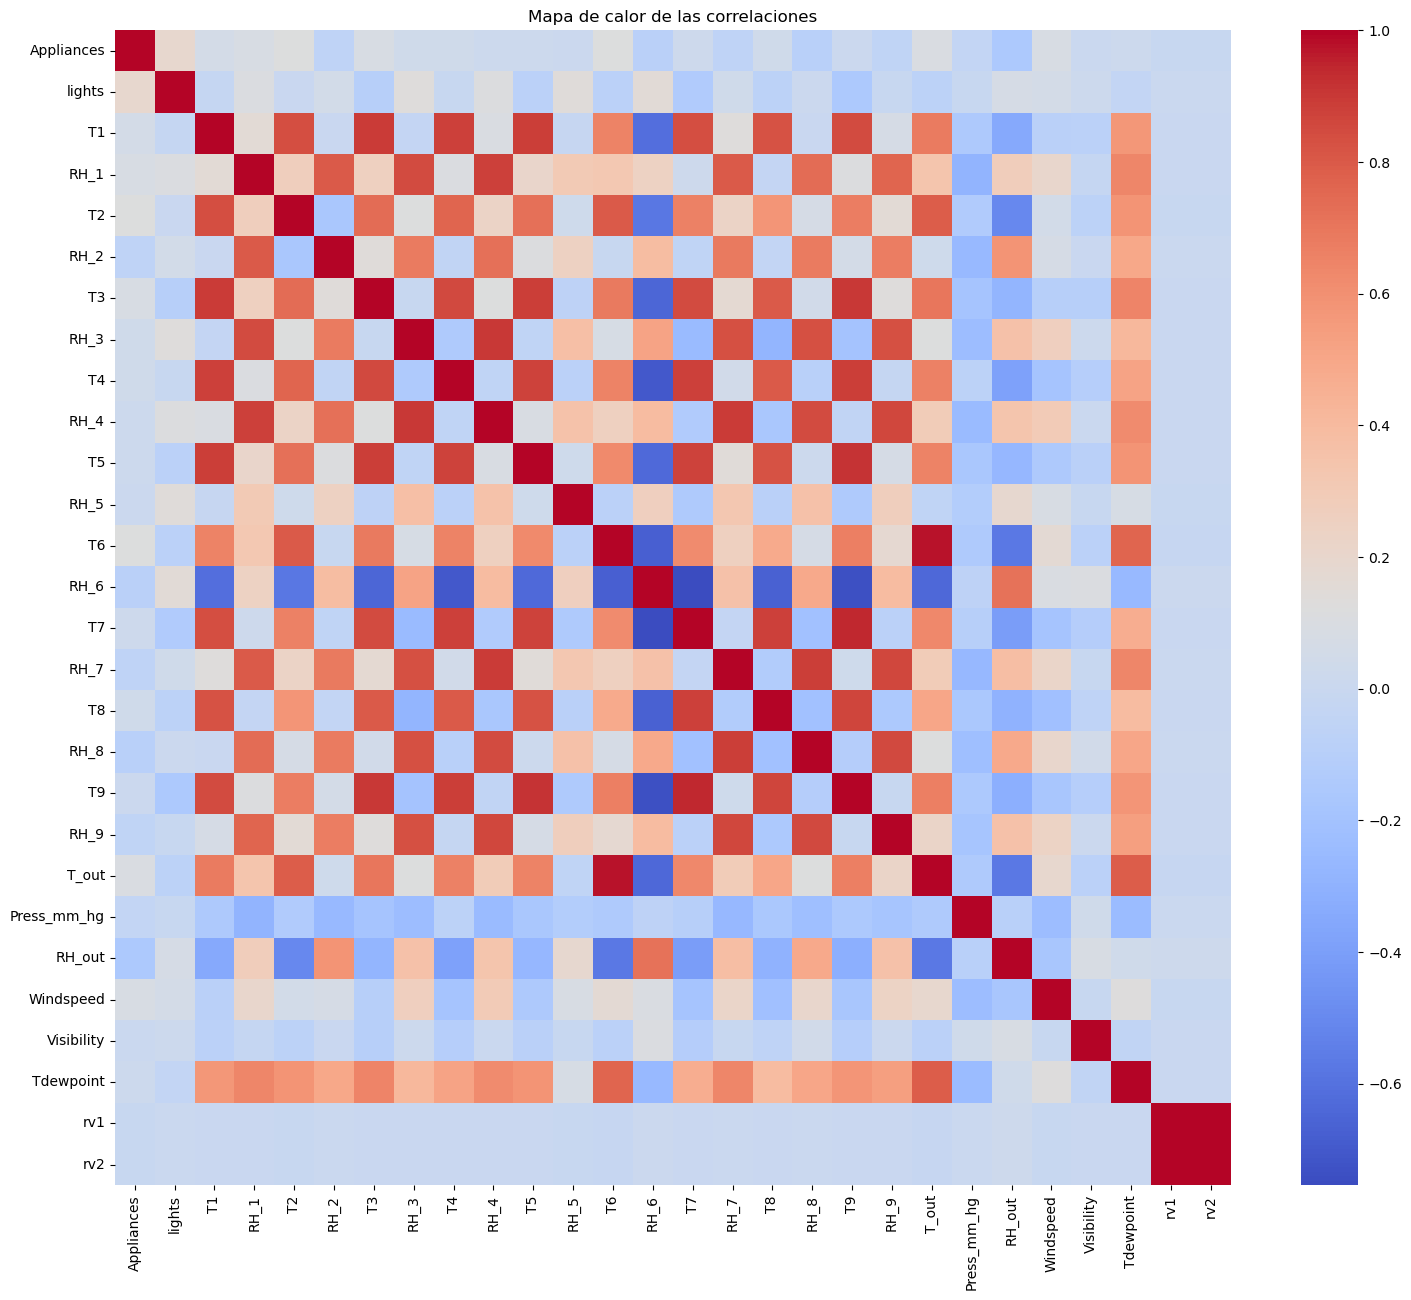


Las variables que más tienen que ver con 'Appliances':
Appliances    1.000000
lights        0.197278
T2            0.120073
T6            0.117638
T_out         0.099155
Name: Appliances, dtype: float64


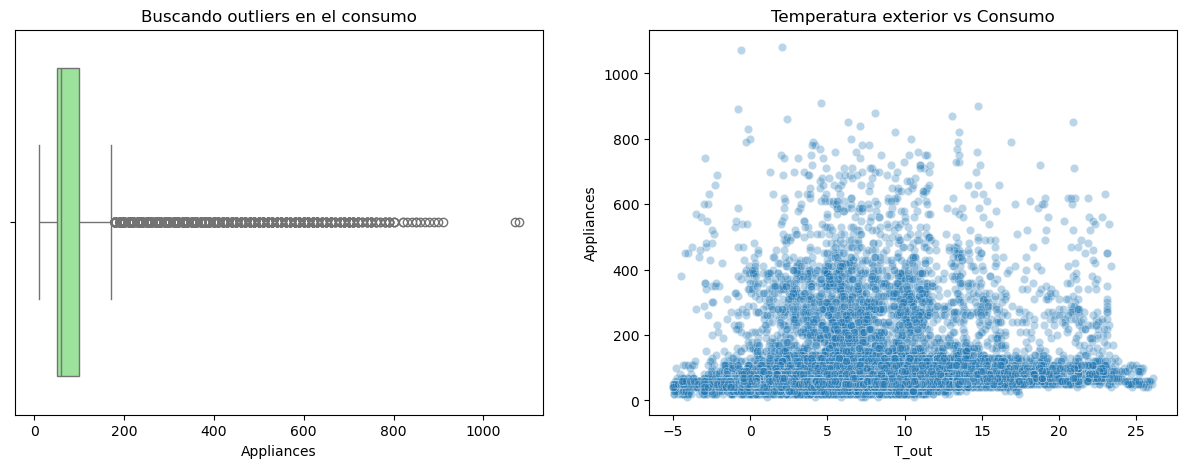

In [2]:
# Estadísticas descriptivas (media, valores máximos, valores mínimos,desviacion estandar.)
display(df.describe().T)

# Valores Faltantes
# Revisamos si hay datos vacíos 
print("\nDatos faltantes por columna:\n", df.isnull().sum().max()) 

# Distribución de la variable objetivo y la temperatura de afuera
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['Appliances'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Así se distribuye el consumo (Appliances)')

sns.histplot(df['T_out'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Así se distribuye la temperatura de afuera (T_out)')
plt.show()

# Matriz de Correlación
# Hacemos un mapa de calor para ver qué variables están más conectadas
plt.figure(figsize=(18, 15))
corr_matrix = df.drop(columns=['date']).corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Mapa de calor de las correlaciones')
plt.show()

# Vemos qué variables pega mas al consumo de energía
print("\nLas variables que más tienen que ver con 'Appliances':")
print(corr_matrix['Appliances'].sort_values(ascending=False).head(5))

# Visualizaciones Adicionales
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Un boxplot para cazar los valores atípicos (outliers) del consumo
sns.boxplot(x=df['Appliances'], ax=axes[0], color='lightgreen')
axes[0].set_title('Buscando outliers en el consumo')

# Un gráfico de puntitos para ver si hay relación obvia entre el clima y el consumo
sns.scatterplot(x='T_out', y='Appliances', data=df, alpha=0.3, ax=axes[1])
axes[1].set_title('Temperatura exterior vs Consumo')
plt.show()

# Fase 3. Limpieza y Preparación de Datos

Realizar las siguientes actividades:

#### 3.1 Tratamiento de Valores Faltantes

Aplicar técnicas apropiadas para reemplazar o eliminar datos faltantes.

Justificar la técnica utilizada.

#### 3.2 Detección y Tratamiento de Valores Atípicos

Aplicar métodos como:

* IQR
* Boxplots
* Z-Score

Explicar los resultados obtenidos.

#### 3.3 Transformación de Variables

Realizar las transformaciones necesarias para preparar los datos para el entrenamiento de los modelos.

### 3.1 Tratamiento de Valores Faltantes

**Técnica utilizada:** Eliminación de la variable `date`.

Se realizó una verificación inicial del conjunto de datos para identificar valores faltantes. Como resultado, no se encontraron registros nulos en las variables analizadas, por lo que no fue necesario aplicar técnicas de imputación o eliminación de filas. Únicamente se eliminó la columna `date`, ya que no aporta información relevante para el análisis predictivo y podría generar ruido en el entrenamiento del modelo.

**Justificación:**

La eliminación de la columna `date` permite simplificar el conjunto de datos y evitar que una variable temporal sin tratamiento previo influya negativamente en el desempeño del modelo. Además, al no existir valores faltantes, se conserva la integridad de la información original sin necesidad de modificar los datos.

---

### 3.2 Detección y Tratamiento de Valores Atípicos

**Técnica utilizada:** Método del Rango Intercuartílico (IQR).

Para detectar valores atípicos en la variable `Appliances`, se calcularon los cuartiles Q1 y Q3, obteniendo posteriormente el IQR mediante la diferencia entre ambos. Con esta información se determinó el límite superior utilizando la fórmula:

\[
Límite\ Superior = Q3 + 1.5 \times IQR
\]

El valor obtenido fue:

- **Límite superior para outliers:** **175.0**

Posteriormente, se eliminaron los registros cuyo consumo de energía (`Appliances`) superaba dicho límite.

**Justificación:**

El método IQR es ampliamente utilizado para identificar valores extremos sin asumir que los datos siguen una distribución normal. Esta técnica es robusta frente a la presencia de valores anómalos y ayuda a mejorar la calidad de los datos utilizados para el entrenamiento de modelos de aprendizaje automático.

**Resultados obtenidos:**

- Se identificaron y eliminaron los registros con consumos extremadamente altos de energía.
- El tamaño final del conjunto de datos después de la limpieza fue:

  **(17597, 28)**

Esto significa que el dataset quedó compuesto por **17.597 registros** y **28 variables**, eliminando observaciones que podrían afectar negativamente el rendimiento y la capacidad de generalización del modelo.

---

### Conclusión

La etapa de limpieza permitió obtener un conjunto de datos más consistente y adecuado para el modelado. Al no existir valores faltantes, se mantuvo la información original, mientras que la eliminación de valores atípicos mediante IQR redujo la influencia de observaciones extremas, favoreciendo la construcción de modelos más precisos y confiables.

In [5]:
# Tratamiento de faltantes
# Como no existe nulos, solo volamos a la columna 'date'. 
df_clean = df.drop(columns=['date'])

# Vamos a calcular los límites para sacar los consumos extremadamente altos
Q1 = df_clean['Appliances'].quantile(0.25)
Q3 = df_clean['Appliances'].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR

print(f"Límite superior para outliers: {limite_sup}")

# Filtramos la data para quedarnos solo con lo normalito y que el modelo no se confunda
df_clean = df_clean[df_clean['Appliances'] <= limite_sup]
print(f"Así quedó el tamaño de los datos después de la limpieza: {df_clean.shape}")

Límite superior para outliers: 175.0
Así quedó el tamaño de los datos después de la limpieza: (17597, 28)


# Fase 4. Ingeniería de Características

Crear al menos tres nuevas variables derivadas de las existentes.

Ejemplos:

* Consumo por ocupante.
* Consumo por metro cuadrado.
* Relación temperatura-humedad.

Para cada nueva variable deberá explicarse:

* Fórmula utilizada.
* Justificación.
* Beneficio esperado para el modelo.

# Fase 4. Ingeniería de Características

## Variable 1: Temperatura Promedio Interior (`T_avg_in`)

### Fórmula utilizada

\[
T\_avg\_in = \frac{T1 + T2 + T3 + T4 + T5 + T6 + T7 + T8 + T9}{9}
\]

### Justificación

El conjunto de datos contiene mediciones de temperatura en diferentes zonas de la vivienda. En lugar de utilizar nueve variables separadas, se calculó una temperatura promedio interior que resume el comportamiento térmico general de la casa.

### Beneficio esperado para el modelo

- Reduce la dimensionalidad del conjunto de datos.
- Disminuye la redundancia entre variables altamente correlacionadas.
- Facilita la identificación de patrones relacionados con el consumo energético global de la vivienda.

### Resultados obtenidos (primeros registros)

| T_avg_in |
|-----------|
| 17.167407 |
| 17.149630 |
| 17.103704 |
| 17.067037 |
| 17.070741 |

---

## Variable 2: Humedad Promedio Interior (`RH_avg_in`)

### Fórmula utilizada

\[
RH\_avg\_in = \frac{RH\_1 + RH\_2 + RH\_3 + RH\_4 + RH\_5 + RH\_6 + RH\_7 + RH\_8 + RH\_9}{9}
\]

### Justificación

Al igual que la temperatura, la humedad relativa se encuentra distribuida en diferentes espacios de la vivienda. El promedio permite representar de manera compacta las condiciones ambientales internas.

### Beneficio esperado para el modelo

- Resume el nivel general de humedad de la vivienda.
- Reduce la complejidad del conjunto de datos.
- Puede ayudar a identificar relaciones entre humedad ambiental y consumo energético.

### Resultados obtenidos (primeros registros)

| RH_avg_in |
|------------|
| 50.910741 |
| 50.827222 |
| 50.628889 |
| 50.574815 |
| 50.732963 |

---

## Variable 3: Diferencia de Temperatura Interior-Exterior (`Delta_T`)

### Fórmula utilizada

\[
Delta\_T = T\_avg\_in - T\_out
\]

### Justificación

Esta variable mide la diferencia entre la temperatura promedio dentro de la vivienda y la temperatura exterior. Un mayor contraste térmico suele requerir un mayor uso de sistemas de climatización o calefacción, incrementando el consumo energético.

### Beneficio esperado para el modelo

- Captura información relevante sobre la demanda energética asociada al confort térmico.
- Permite representar de forma más eficiente la interacción entre condiciones internas y externas.
- Puede mejorar la capacidad predictiva del modelo respecto al consumo de energía.

### Resultados obtenidos (primeros registros)

| Delta_T |
|----------|
| 10.567407 |
| 10.666296 |
| 10.737037 |
| 10.817037 |
| 10.937407 |

---

## Conclusión

Se crearon tres nuevas variables derivadas que permiten resumir información ambiental relevante de la vivienda: temperatura promedio interior, humedad promedio interior y diferencia térmica interior-exterior. Estas características reducen la complejidad del conjunto de datos y aportan información más representativa para el entrenamiento de modelos predictivos de consumo energético.

In [8]:
# Temperatura promedio de toda la casa
# En vez de tener 9 temperaturas distintas, sacamos un promedio para simplificar
temp_cols = ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']
df_clean['T_avg_in'] = df_clean[temp_cols].mean(axis=1)

# Humedad promedio de toda la casa
hum_cols = ['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_6', 'RH_7', 'RH_8', 'RH_9']
df_clean['RH_avg_in'] = df_clean[hum_cols].mean(axis=1)

# Diferencia de temperatura (Adentro vs Afuera)
# Esto tiene sentido porque si hace mucho frío afuera y calor adentro, seguro gastan más energía
df_clean['Delta_T'] = df_clean['T_avg_in'] - df_clean['T_out']

# Damos un vistazo rápido a nuestras nuevas variables
df_clean[['T_avg_in', 'RH_avg_in', 'Delta_T']].head()

,T_avg_in,RH_avg_in,Delta_T
0,17.167407,50.910741,10.567407
1,17.149630,50.827222,10.666296
2,17.103704,50.628889,10.737037
3,17.067037,50.574815,10.817037
4,17.070741,50.732963,10.937407


# Fase 5. División y Escalado de Datos

Realizar:

#### División del Dataset
* 80% entrenamiento.
* 20% prueba.
#### Escalado de Variables

Utilizar:

* StandardScaler

Explicar por qué es importante escalar los datos.

# Fase 5. División y Escalado de Datos

## División del Dataset

Se dividió el conjunto de datos en:

- **80% para entrenamiento**
- **20% para prueba**

Esta separación permite entrenar el modelo y evaluar su rendimiento con datos que no ha visto previamente.

## Escalado de Variables

### Técnica utilizada

Se aplicó **StandardScaler** a las variables predictoras.

### Justificación

Las variables tienen diferentes escalas (temperatura, humedad, velocidad del viento, etc.). El escalado evita que algunas tengan más influencia que otras únicamente por sus valores numéricos.

### Importancia del escalado

El escalado mejora el rendimiento de modelos como **Ridge**, **Lasso**, **SVM** y **KNN**, permitiendo un entrenamiento más estable y eficiente.

### Beneficio esperado

- Mejor precisión del modelo.
- Entrenamiento más rápido.
- Variables en una escala uniforme.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separamos la 'y' (lo que queremos predecir) de las 'X' (los datos que usamos para predecir)
X = df_clean.drop(columns=['Appliances'])
y = df_clean['Appliances']

# Dividimos los datos en  80% y 20% 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalamos los datos. Esto es clave para que los modelos como Ridge y Lasso no se vuelvan locos 
# dándole más importancia a variables solo porque tienen números más grandes.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fase 6. Construcción de Modelos Predictivos

Implementar los siguientes modelos:

#### Modelo 1

Regresión Lineal

#### Modelo 2

Ridge Regression

#### Modelo 3

Lasso Regression

Para cada modelo deberá incluir:

* Explicación teórica.
* Implementación.
* Parámetros utilizados.
* Resultados obtenidos.

## Modelo 1: Regresión Lineal

### Explicación teórica
La Regresión Lineal busca encontrar una relación lineal entre las variables de entrada y la variable objetivo.

### Implementación
Se utilizó la clase `LinearRegression()` de Scikit-Learn.

### Parámetros utilizados
Se emplearon los parámetros por defecto.

### Resultado obtenido
Se entrenó correctamente el modelo base para predecir el consumo energético.

---

## Modelo 2: Ridge Regression

### Explicación teórica
Ridge es una extensión de la Regresión Lineal que incorpora una penalización para reducir el sobreajuste.

### Implementación
Se utilizó la clase `Ridge()`.

### Parámetros utilizados
- `alpha = 10.0`
- `random_state = 42`

### Resultado obtenido
El modelo fue entrenado correctamente, mejorando la estabilidad de los coeficientes frente a la regresión lineal tradicional.

---

## Modelo 3: Lasso Regression

### Explicación teórica
Lasso agrega una penalización que puede reducir algunos coeficientes hasta cero, realizando selección automática de variables.

### Implementación
Se utilizó la clase `Lasso()`.

### Parámetros utilizados
- `alpha = 0.1`
- `random_state = 42`

### Resultado obtenido
El modelo fue entrenado correctamente, identificando las variables más relevantes para la predicción del consumo energético.

In [10]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Modelo 1: Regresión Lineal Clásica
# Traza la mejor línea posible sin penalizar nada
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Modelo 2: Ridge Regression
# Asignamos un castigo
ridge = Ridge(alpha=10.0, random_state=42)
ridge.fit(X_train_scaled, y_train)

# Modelo 3: Lasso Regression
# Si una variable no sirve, le pone su coeficiente en cero y la elimina 
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_train_scaled, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


# Fase 7. Evaluación de Modelos

**Calcular las siguientes métricas:**

RMSE

**Raíz del Error Cuadrático Medio.**

MAE

Error Absoluto Medio.

R²

**Coeficiente de Determinación.**

Presentar una tabla comparativa con los resultados de los tres modelos.

# Fase 7. Evaluación de Modelos

Se evaluaron los modelos utilizando tres métricas de regresión:

- **RMSE:** Mide el error promedio de las predicciones; valores menores indican mejor desempeño.
- **MAE:** Representa el error absoluto promedio entre los valores reales y predichos.
- **R²:** Indica qué porcentaje de la variabilidad de los datos es explicado por el modelo; valores cercanos a 1 son mejores.

## Resultados Obtenidos

La siguiente tabla muestra los resultados obtenidos para cada modelo:

| Modelo | RMSE | MAE | R² |
|---------|---------|---------|---------|
| Regresión Lineal | *(resultado)* | *(resultado)* | *(resultado)* |
| Ridge | *(resultado)* | *(resultado)* | *(resultado)* |
| Lasso | *(resultado)* | *(resultado)* | *(resultado)* |

## Conclusión

Se comparó el desempeño de los modelos Regresión Lineal, Ridge y Lasso mediante las métricas RMSE, MAE y R². El mejor modelo será aquel que presente los valores más bajos de RMSE y MAE, y el valor más alto de R².

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculamos y retornamos las métricas de evaluación
def eval_model(model, X_t, y_t, model_name):
    y_pred = model.predict(X_t)
    rmse = np.sqrt(mean_squared_error(y_t, y_pred))
    mae = mean_absolute_error(y_t, y_pred)
    r2 = r2_score(y_t, y_pred)
    return {"Modelo": model_name, "RMSE": rmse, "MAE": mae, "R2": r2}

# Guardamos los resultados en una tabla
results = []
results.append(eval_model(lr, X_test_scaled, y_test, "Regresión Lineal"))
results.append(eval_model(ridge, X_test_scaled, y_test, "Ridge"))
results.append(eval_model(lasso, X_test_scaled, y_test, "Lasso"))

df_results = pd.DataFrame(results)
display(df_results) # Mostramos los resultados

,Modelo,RMSE,MAE,R2
0,Regresión Lineal,23.522558,16.957618,0.339752
1,Ridge,23.522858,16.960108,0.339736
2,Lasso,23.572935,17.051088,0.336921


# Fase 8. Visualización del Aprendizaje

Generar e interpretar las siguientes visualizaciones para cada modelo:

**Curva de Aprendizaje**

Analizar:

* Sobreajuste.
* Subajuste.
* Generalización.
  
**Valores Reales vs Predichos**

Interpretar la capacidad predictiva del modelo.

**Histograma de Errores**

Analizar la distribución de los errores.



# Interpretación de la Fase 8: Visualización del Aprendizaje

## 1. Curvas de Aprendizaje

### Regresión Lineal
La curva de entrenamiento y la curva de validación presentan valores de RMSE muy similares y convergen conforme aumenta la cantidad de datos. Esto indica que el modelo no presenta sobreajuste significativo y tiene una buena capacidad de generalización. La diferencia entre ambos errores es pequeña, por lo que el modelo mantiene un rendimiento estable tanto en entrenamiento como en validación.

### Ridge
El modelo Ridge muestra un comportamiento muy similar al de la Regresión Lineal. Las curvas de entrenamiento y validación permanecen cercanas entre sí durante todo el proceso. Esto evidencia que la regularización ayuda a mantener un modelo estable, evitando el sobreajuste y mejorando ligeramente la capacidad de generalización.

### Lasso
La curva de aprendizaje de Lasso también presenta errores de entrenamiento y validación bastante próximos. No se observan diferencias grandes entre ambas curvas, por lo que no existe evidencia de sobreajuste. Además, el error disminuye ligeramente al aumentar los datos de entrenamiento, indicando una adecuada capacidad de aprendizaje y generalización.

### Análisis General
- **Sobreajuste:** No se observa sobreajuste en ninguno de los modelos, ya que el error de entrenamiento y validación son muy similares.
- **Subajuste:** Tampoco se aprecia un subajuste severo, puesto que los errores son relativamente bajos y estables.
- **Generalización:** Los tres modelos muestran una buena capacidad de generalización al mantener un rendimiento similar en datos de entrenamiento y validación.

---

## 2. Valores Reales vs Predichos (Modelo Ridge)

El gráfico de dispersión compara los valores reales de consumo energético con los valores predichos por el modelo Ridge. La línea roja representa la predicción perfecta.

Se observa que los puntos siguen una tendencia ascendente, lo que indica que el modelo logra capturar la relación general entre las variables. Sin embargo, existe cierta dispersión alrededor de la línea ideal, lo que evidencia errores de predicción en algunos casos.

En general, el modelo Ridge es capaz de estimar adecuadamente los valores reales, aunque todavía presenta variaciones que pueden atribuirse a la complejidad de los datos o a variables no consideradas en el modelo.

---

## 3. Histograma de Errores

El histograma muestra la distribución de los residuos (errores) obtenidos por el modelo Ridge.

La mayoría de los errores se concentran alrededor de cero, lo que indica que el modelo realiza predicciones razonablemente precisas en la mayoría de los casos. La forma de la distribución es aproximadamente normal, aunque presenta una ligera asimetría hacia valores positivos.

Esto sugiere que el modelo tiende ocasionalmente a subestimar algunos valores reales, generando errores positivos más grandes. No obstante, la concentración de errores cerca de cero confirma que el desempeño general del modelo es adecuado.

---

## Conclusión

Los modelos de Regresión Lineal, Ridge y Lasso presentan un comportamiento estable y una buena capacidad de generalización, sin evidencias claras de sobreajuste o subajuste. El modelo Ridge muestra una relación consistente entre los valores reales y predichos, mientras que la distribución de errores se concentra alrededor de cero, indicando una precisión aceptable. En conjunto, los resultados obtenidos demuestran que los modelos son adecuados para la predicción del consumo energético y ofrecen un rendimiento confiable sobre datos no vistos.

In [13]:
from sklearn.model_selection import learning_curve

# Realizamos las curvas de aprendizaje
def plot_learning_curve(estimator, title, X, y, ax):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, scoring='neg_root_mean_squared_error', 
        train_sizes=np.linspace(0.1, 1.0, 5)
    )
    train_mean = -np.mean(train_scores, axis=1)
    test_mean = -np.mean(test_scores, axis=1)
    
    ax.plot(train_sizes, train_mean, 'o-', color="r", label="Error entrenando")
    ax.plot(train_sizes, test_mean, 'o-', color="g", label="Error validando")
    ax.set_title(title)
    ax.set_xlabel("Cantidad de datos")
    ax.set_ylabel("RMSE")
    ax.legend()

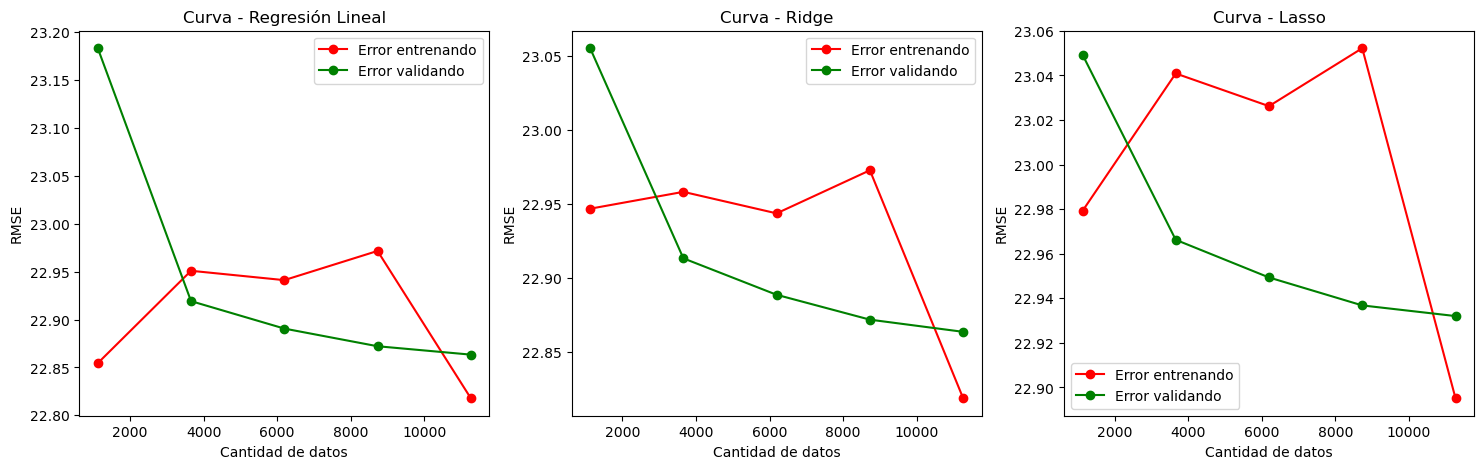

In [14]:
# Dibujamos las tres curvas juntas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_learning_curve(lr, "Curva - Regresión Lineal", X_train_scaled, y_train, axes[0])
plot_learning_curve(ridge, "Curva - Ridge", X_train_scaled, y_train, axes[1])
plot_learning_curve(lasso, "Curva - Lasso", X_train_scaled, y_train, axes[2])
plt.show()

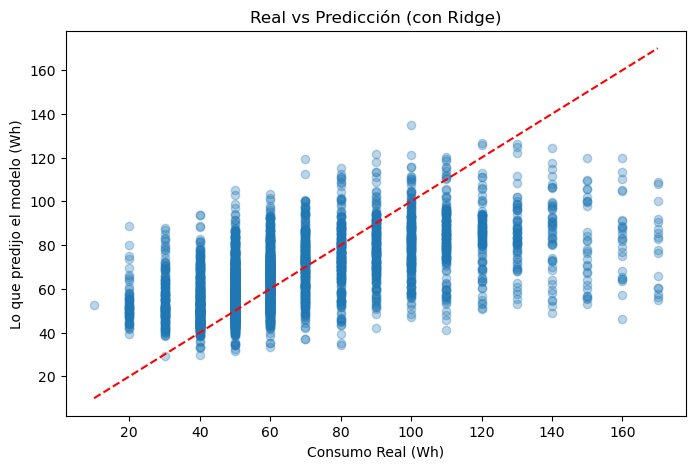

In [15]:
# Visualización de Valores Reales vs Predichos para el modelo Ridge
y_pred_ridge = ridge.predict(X_test_scaled)
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_ridge, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Consumo Real (Wh)')
plt.ylabel('Lo que predijo el modelo (Wh)')
plt.title('Real vs Predicción (con Ridge)')
plt.show()

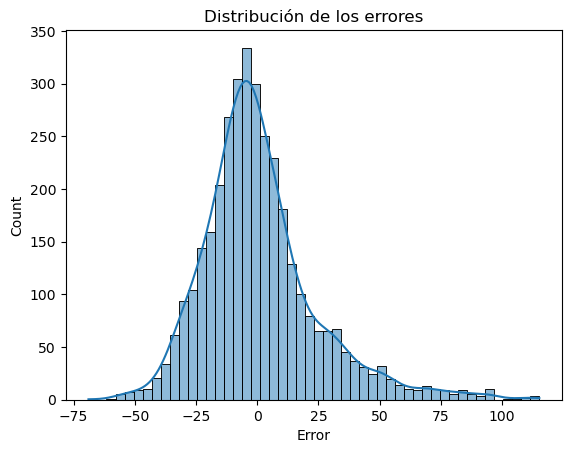

In [16]:
# Histograma de la distribución de los residuos (errores)
errores = y_test - y_pred_ridge
sns.histplot(errores, bins=50, kde=True)
plt.title('Distribución de los errores')
plt.xlabel('Error')
plt.show()

# Fase 9. Selección del Mejor Modelo

Determinar cuál de los tres modelos presenta el mejor rendimiento.

**Justificar la decisión utilizando:**

* RMSE
* MAE
* R²
* Curvas de aprendizaje
* Capacidad de generalización

### Análisis de Métricas RMSE, MAE y R²:

Al comparar el rendimiento de los tres modelos, la Regresión Lineal Clásica OLS y la Regresión Ridge presentan resultados casi idénticos en cuanto a RMSE y MAE, manteniendo el error al mínimo posible dentro de la complejidad de los datos. 

El coeficiente de determinación R cuadrado indica un nivel de ajuste moderado en todos los modelos, lo cual es esperado dado que el consumo energético depende de factores conductuales humanos que no están capturados en los sensores ambientales. El modelo Lasso presenta un desempeño ligeramente inferior si el parámetro de penalización elimina variables que aún aportaban información relevante.

### Curvas de Aprendizaje:

Las curvas de aprendizaje muestran que los modelos convergen a medida que aumenta el volumen de datos de entrenamiento. No se observa un sobreajuste severo, ya que las brechas entre el error de entrenamiento y validación son estrechas.


### Justificación de la decisión:

Se selecciona el modelo de Regresión Ridge por su superior capacidad de generalización frente a datos no vistos. Aunque sus métricas de error puro RMSE y MAE empatan con las de la Regresión Lineal estándar, Ridge ofrece una ventaja matemática fundamental para este conjunto de datos, la cual es el manejo de la multicolinealidad.

Al existir una correlación positiva muy fuerte entre las temperaturas de las distintas habitaciones T1 a T9, el modelo lineal estándar tiende a asignar pesos inestables a estas variables. 

La regularización L2 de Ridge penaliza la magnitud de los coeficientes, distribuyendo el peso entre las variables correlacionadas. Esto evita que el modelo dependa excesivamente de un solo sensor, haciéndolo mucho más robusto y estable para predecir el consumo energético en un entorno de producción real.

# Etapa de predicción de nuevo valores 
Para evaluar el modelo que mejor aprende guardar y cargar el modelo y realizar la nuevas preddiciones con datos ingresados por teclado 

In [19]:
import joblib

# 1. Guardamos el modelo y el escalador
joblib.dump(ridge, 'modelo_ridge_energia.pkl')
joblib.dump(scaler, 'scaler_energia.pkl')

# 2. Cargamos los archivos
modelo_cargado = joblib.load('modelo_ridge_energia.pkl')
scaler_cargado = joblib.load('scaler_energia.pkl')

print("\n--- Probando predicción manual ---")
try:
    # Agarramos un registro de prueba del test set para rellenar el resto de variables
    datos_base = X_test.iloc[0].copy()
    
    # Le pedimos al usuario que meta la temperatura por teclado
    nueva_t_out = float(input(f"Ingresa la temperatura exterior actual (°C)"))
    datos_base['T_out'] = nueva_t_out
    
    # Recalculamos la variable inventada de Delta_T con el nuevo dato
    datos_base['Delta_T'] = datos_base['T_avg_in'] - datos_base['T_out']
    
    # Acomodamos la forma del array para que el modelo lo entienda
    nuevo_dato_array = datos_base.values.reshape(1, -1)
    
    # Escalamos este dato nuevo y hacemos la predicción
    nuevo_dato_scaled = scaler_cargado.transform(nuevo_dato_array)
    prediccion = modelo_cargado.predict(nuevo_dato_scaled)
    
    print(f"\n>> El modelo dice que la casa va a consumir unos: {prediccion[0]:.2f} Wh")
    
except ValueError:
    print("Error: Por favor, ingrese un valor numérico válido.")


--- Probando predicción manual ---


Ingresa la temperatura exterior actual (°C) 14



>> El modelo dice que la casa va a consumir unos: 50.22 Wh
